In [1]:
from PIL import Image #open imgs for v1, v2
import matplotlib.pyplot as plt #plot imgs
import cv2 #for v3
import os #file and image management
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import re #regular expressions
import torch
import numpy as np
import sys
import math
from PIL import ImageFilter


In [2]:
import transformers

In [4]:
from transformers import pipeline #easy pipeline for DA models



In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu" #set device as GPU if available

models = {
    "V1": "LiheYoung/depth-anything-base-hf",
    "V2": "depth-anything/Depth-Anything-V2-base-hf",
    # "V3": "qualcomm/Depth-Anything-V3"
}


    
pipelines = {}
print("\nLoading models")
for version, repo in models.items():
    try:
        pipelines[version] = pipeline(task="depth-estimation", model=repo, device=device, torch_dtype=torch.float32)
        print(f" {version} loaded successfully.")
    except Exception as e:
        print(f" Couldn't Load {version}.")


# v3_model_path = os.path.join(v3_root, "checkpoints", "DA3NESTED-BASE") 




Loading models


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


 V1 loaded successfully.


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

 V2 loaded successfully.


In [6]:

current_dir = os.getcwd()
v3_folder = os.path.join(current_dir, "depth-anything-3")
v3_src = os.path.join(v3_folder, "src")

if v3_src not in sys.path:
    sys.path.insert(0, v3_src)

# set device
device = "cuda" if torch.cuda.is_available() else "cpu"

print("--- loading depth anything v3 local (base) ---")
try:
    # now that the folder is next to the notebook, this should work
    from depth_anything_3.api import DepthAnything3
    
    # attempt to load the base model
    # note: if you get a 401 error, we will need to point to a local .pth file
    model = DepthAnything3.from_pretrained("depth-anything/DA3-BASE")
    model = model.to(device=torch.device(device))
    
    pipelines["V3"] = model
    print(" v3 base loaded successfully from local folder.")
except ModuleNotFoundError as e:
    print(f" import error: {e}. check if 'depth-anything-3/src/depth_anything_3' exists.")
except Exception as e:
    print(f" load failed: {e}")

--- loading depth anything v3 local (base) ---
[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.7.1+cu126 with CUDA 1208 (you have 2.7.1+cu118)
    Python  3.9.13 (you have 3.10.10)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


[INFO ] using MLP layer as FFN
 v3 base loaded successfully from local folder.


In [7]:
def compare_single_image(image_path, save_path=None):
    """
    runs all available models (v1, v2, v3) and plots them with unified color logic
    """
    try:
        available_models = sorted(pipelines.keys())
        if not available_models: return

        # setup naming
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        clean_name = re.sub(r'\d+', '', base_name).replace('_', ' ').strip().title()

        img_pil = Image.open(image_path).convert("RGB")
        img_np = np.array(img_pil)
        
        results = {}
        for version in available_models:
            model = pipelines[version]
            if version == "V3":
                prediction = model.inference([img_np])
                # v3 output is often disparity (higher = closer)
                # we keep it raw here and handle logic in the plotting loop
                results[version] = prediction.depth[0]
            else:
                res = model(img_pil, timeout=None)
                results[version] = res["predicted_depth"].squeeze().cpu().numpy()

        num_plots = len(results) + 1
        fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
        if num_plots == 1: axes = [axes]
        fig.suptitle(clean_name, fontsize=14, fontweight='bold', y=0.98)

        # 0. original image
        axes[0].imshow(img_pil)
        axes[0].set_title("Original Image", fontsize=10, fontweight='bold')
        axes[0].axis('off')

        # 1-N. depth maps
        for i, version in enumerate(available_models):
            depth_map_ptr = np.array(results[version])
            
            # basic normalization: 0 to 1
            d_min, d_max = depth_map_ptr.min(), depth_map_ptr.max()
            depth_norm = (depth_map_ptr - d_min) / (d_max - d_min + 1e-8)

            # logical check for v3
            # if the floor/bottom of the ames room is darker than the ceiling, it's inverted
            # standard: closer objects (bottom of image usually) should be lighter (yellow/white)
            if version == "V3":
                # we force v3 to match v1/v2 orientation
                # usually v1/v2: close = high value (light)
                # if your v3 is showing close = dark, we flip it
                # current evidence shows v3 needs flipping to match v1/v2 behavior
                depth_norm = 1.0 - depth_norm

            axes[i+1].imshow(depth_norm, cmap='inferno', interpolation="bilinear")
            axes[i+1].set_title(f"Depth Anything {version}", fontsize=10, fontweight='bold')
            axes[i+1].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.92])

        if save_path:
            plt.savefig(save_path, dpi=200, bbox_inches='tight')
            plt.close(fig)
        else:
            plt.show()

    except Exception as e:
        print(f" error in compare_single_image: {e}")

def process_dataset(input_folder="3D_illusions", output_folder="results"):
    """
    automates processing for the entire directory structure
    """
    # final check before starting
    print(f"models currently loaded: {list(pipelines.keys())}")
    # print(f"starting batch processing...")
    
    total = 0
    if not os.path.exists(input_folder):
        print(f" error: input folder '{input_folder}' not found.")
        return

    for root, dirs, files in os.walk(input_folder):
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                
                # maintain subdirectory structure
                rel_path = os.path.relpath(root, input_folder)
                target_dir = os.path.join(output_folder, rel_path)
                os.makedirs(target_dir, exist_ok=True)
                
                save_path = os.path.join(target_dir, f"cmp_{filename}")
                
                print(f" processing -> {filename}")
                compare_single_image(img_path, save_path=save_path)
                total += 1

    print(f"dataset processing complete. total images: {total}")

# execute
# process_dataset()

In [ ]:
process_dataset(input_folder="synthetic data/corridor_illusion", output_folder="synthetic_results") #for the corridor illusion

models currently loaded: ['V1', 'V2', 'V3']
 processing -> base_image.png
[INFO ] Processed Images Done taking 0.028921842575073242 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.06757259368896484 seconds
[INFO ] Conversion to Prediction Done. Time: 0.000997781753540039 seconds
 processing -> cube_walls.jpg
[INFO ] Processed Images Done taking 0.013963460922241211 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.08509469032287598 seconds
[INFO ] Conversion to Prediction Done. Time: 0.000997304916381836 seconds
 processing -> cylinder_pattern.png
[INFO ] Processed Images Done taking 0.026926517486572266 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.07308721542358398 seconds
[INFO ] Conversion to Prediction Done. Time: 0.000997781753540039 seconds
 processing -> cylinder_pattern_bordered.png
[INFO ] Processed Images Done taking 0.012859106063842773 seconds. Shape:  torch

In [40]:
process_dataset(input_folder="Minecraft Experiments", output_folder="Minecraft_Results") #Minecraft Experiments

models currently loaded: ['V1', 'V2', 'V3']
 processing -> converging_tunnel.png
[INFO ] Processed Images Done taking 0.06837725639343262 seconds. Shape:  torch.Size([1, 3, 266, 504])
[INFO ] Model Forward Pass Done. Time: 0.1378004550933838 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0009975433349609375 seconds
 processing -> converging_tunnel_zoomed.png
[INFO ] Processed Images Done taking 0.02094435691833496 seconds. Shape:  torch.Size([1, 3, 266, 504])
[INFO ] Model Forward Pass Done. Time: 0.05396318435668945 seconds
[INFO ] Conversion to Prediction Done. Time: 0.000997781753540039 seconds
 processing -> flat_grid.png
[INFO ] Processed Images Done taking 0.02098703384399414 seconds. Shape:  torch.Size([1, 3, 266, 504])
[INFO ] Model Forward Pass Done. Time: 0.05192065238952637 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0 seconds
 processing -> grid_pattern.png
[INFO ] Processed Images Done taking 0.01950812339782715 seconds. Shape:  torch.Size([1, 3, 266, 50

In [8]:
import cv2
import numpy as np
import os
import csv

rectangles = []
drawing = False
ix, iy = -1, -1
img_with_commands = None
raw_img = None
scale_ratio = 1.0
display_offset = 0
orig_offset = 0
banner_h = 40
num_panels = 4
last_category = ""

def draw_rect(event, x, y, flags, param):
    """handles click-and-drag to draw bounding boxes."""
    global ix, iy, drawing, img_with_commands, rectangles, display_offset, banner_h, num_panels
    
    if event == cv2.EVENT_LBUTTONDOWN:
        if y < banner_h: return # ignore clicks on banner
        if x > display_offset: return # force drawing on panel 1 only
        drawing = True
        ix, iy = x, y
        
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            temp_img = img_with_commands.copy()
            for i in range(num_panels):
                nx1, nx2 = ix + i * display_offset, x + i * display_offset
                cv2.rectangle(temp_img, (nx1, iy), (nx2, y), (0, 255, 255), 1)
            cv2.imshow("tfg_lab", temp_img)
            
    elif event == cv2.EVENT_LBUTTONUP:
        if drawing:
            drawing = False
            x1, x2 = min(ix, x), max(ix, x)
            y1, y2 = min(iy, y), max(iy, y)
            
            # prevent accidental tiny clicks
            if x2 - x1 > 2 and y2 - y1 > 2:
                rectangles.append((x1, y1, x2, y2))
                for i in range(num_panels):
                    nx1, nx2 = x1 + i * display_offset, x2 + i * display_offset
                    cv2.rectangle(img_with_commands, (nx1, y1), (nx2, y2), (0, 255, 0), 2)
                    cv2.putText(img_with_commands, f"roi{len(rectangles)}", (nx1, y1-5), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
                cv2.imshow("tfg_lab", img_with_commands)

def run_tfg_experiment(results_path="results", output_path="ROI_results"):
    global rectangles, img_with_commands, raw_img, scale_ratio, display_offset, orig_offset, banner_h, num_panels, last_category
    
    os.makedirs(output_path, exist_ok=True)
    csv_file = os.path.join(output_path, "tfg_roi_metrics.csv")
    
    if not os.path.exists(csv_file):
        with open(csv_file, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["category", "image", "model", "roi_id", "area_px", "mean_intensity", "gap_with_prev_roi"])

    for category in sorted(os.listdir(results_path)):
        cat_path = os.path.join(results_path, category)
        if not os.path.isdir(cat_path): continue

        if category != last_category:
            with open(csv_file, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(["---", f"CATEGORY: {category.upper()}", "---", "---", "---", "---", "---"])
            last_category = category

        valid_ext = ('.png', '.jpg', '.jpeg', '.bmp')
        image_files = [f for f in os.listdir(cat_path) if f.lower().endswith(valid_ext)]

        for filename in image_files:
            print(f"\n--- analyzing: {filename} ---")
            
            target_path = os.path.join(cat_path, filename)
            raw_img = cv2.imread(target_path, cv2.IMREAD_GRAYSCALE)
            if raw_img is None: continue
            
            h, w_total = raw_img.shape
            
            # auto-detect offset logic
            analysis_region = raw_img[int(h*0.15):int(h*0.95), :]
            _, thresh = cv2.threshold(analysis_region, 240, 255, cv2.THRESH_BINARY_INV)
            col_sums = np.sum(thresh, axis=0)
            content_cols = np.where(col_sums > 20)[0]
            
            if len(content_cols) > 0:
                jumps = np.where(np.diff(content_cols) > 15)[0]
                clusters = []
                start_idx = 0
                for j in jumps:
                    clusters.append((content_cols[start_idx], content_cols[j]))
                    start_idx = j + 1
                clusters.append((content_cols[start_idx], content_cols[-1]))
                
                if len(clusters) >= 4:
                    centers = [(start + end) / 2.0 for start, end in clusters]
                    orig_offset = int(np.mean(np.diff(centers[:4])))
                else:
                    orig_offset = w_total // num_panels
            else:
                orig_offset = w_total // num_panels
            
            max_w, max_h = 1800, 800
            scale_ratio = min(max_w/w_total, max_h/h, 1.0)
            new_w, new_h = int(w_total * scale_ratio), int(h * scale_ratio)
            display_offset = int(orig_offset * scale_ratio)
            
            base_display = cv2.cvtColor(cv2.resize(raw_img, (new_w, new_h)), cv2.COLOR_GRAY2BGR)
            
            img_with_commands = np.zeros((new_h + banner_h, new_w, 3), dtype=np.uint8)
            img_with_commands[banner_h:, :] = base_display
            
            cv2.putText(img_with_commands, "keys: [s] save | [r] reset | [n] next  --  DRAG to draw rectangles on panel 1", 
                        (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
            rectangles = []
            cv2.namedWindow("tfg_lab", cv2.WINDOW_AUTOSIZE)
            cv2.setMouseCallback("tfg_lab", draw_rect)
            
            break_all = False
            while True:
                cv2.imshow("tfg_lab", img_with_commands)
                key = cv2.waitKey(1) & 0xFF
                
                if key == ord('s'):
                    out_img = cv2.cvtColor(raw_img, cv2.COLOR_GRAY2BGR)
                    
                    with open(csv_file, mode='a', newline='') as f:
                        writer = csv.writer(f)
                        means = {"orig": [], "v1": [], "v2": [], "v3": []}
                        
                        for i, (px1, py1, px2, py2) in enumerate(rectangles):
                            # map back to original resolution coordinates
                            true_y1, true_y2 = py1 - banner_h, py2 - banner_h
                            ox1, oy1 = int(px1 / scale_ratio), int(true_y1 / scale_ratio)
                            ox2, oy2 = int(px2 / scale_ratio), int(true_y2 / scale_ratio)
                            
                            area = (ox2 - ox1) * (oy2 - oy1)
                            
                            # extract roi blocks
                            roi_orig = raw_img[oy1:oy2, ox1:ox2]
                            roi_v1 = raw_img[oy1:oy2, ox1 + orig_offset : ox2 + orig_offset]
                            roi_v2 = raw_img[oy1:oy2, ox1 + 2 * orig_offset : ox2 + 2 * orig_offset]
                            roi_v3 = raw_img[oy1:oy2, ox1 + 3 * orig_offset : ox2 + 3 * orig_offset]
                            
                            # calculate means
                            mean_orig = round(np.mean(roi_orig), 2)
                            mean_v1 = round(np.mean(roi_v1), 2)
                            mean_v2 = round(np.mean(roi_v2), 2)
                            mean_v3 = round(np.mean(roi_v3), 2)
                            
                            means["orig"].append(mean_orig)
                            means["v1"].append(mean_v1)
                            means["v2"].append(mean_v2)
                            means["v3"].append(mean_v3)
                            
                            # gap against previous ROI (pairwise logic)
                            gap_orig = round(abs(mean_orig - means["orig"][i-1]), 2) if i % 2 == 1 else 0.0
                            gap_v1 = round(abs(mean_v1 - means["v1"][i-1]), 2) if i % 2 == 1 else 0.0
                            gap_v2 = round(abs(mean_v2 - means["v2"][i-1]), 2) if i % 2 == 1 else 0.0
                            gap_v3 = round(abs(mean_v3 - means["v3"][i-1]), 2) if i % 2 == 1 else 0.0
                            
                            writer.writerow([category, filename, "orig", i+1, area, mean_orig, gap_orig])
                            writer.writerow([category, filename, "v1", i+1, area, mean_v1, gap_v1])
                            writer.writerow([category, filename, "v2", i+1, area, mean_v2, gap_v2])
                            writer.writerow([category, filename, "v3", i+1, area, mean_v3, gap_v3])
                            
                            # draw rectangles and mean values on final image
                            for j, m_val in enumerate([mean_orig, mean_v1, mean_v2, mean_v3]):
                                curr_x1 = ox1 + j * orig_offset
                                curr_x2 = ox2 + j * orig_offset
                                cv2.rectangle(out_img, (curr_x1, oy1), (curr_x2, oy2), (0, 255, 0), 2)
                                cv2.putText(out_img, f"r{i+1}: {m_val}", (curr_x1, oy1-10), 
                                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                    
                    out_dir = os.path.join(output_path, category)
                    os.makedirs(out_dir, exist_ok=True)
                    cv2.imwrite(os.path.join(out_dir, f"analisis_{filename}"), out_img)
                    print("  -> saved successfully.")
                    break
                
                elif key == ord('r'):
                    img_with_commands[banner_h:, :] = base_display
                    img_with_commands[:banner_h, :] = 0
                    cv2.putText(img_with_commands, "keys: [s] save | [r] reset | [n] next  --  DRAG to draw rectangles on panel 1", 
                                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
                    rectangles = []
                
                elif key == ord('n'):
                    break
                
                elif key == 27:
                    break_all = True
                    break
            
            if break_all: break
        if break_all: break

    cv2.destroyAllWindows()

# run_tfg_experiment()
# run_tfg_experiment(results_path="synthetic_results", output_path="Synthetic_ROI_results")
# run_tfg_experiment(results_path="Minecraft_Results", output_path="Minecraft_ROI_results")


In [9]:
import os
import numpy as np
from PIL import Image, ImageDraw

#root directory using a relative path
#this points to your tfg experiments folder
root_dir = "Psychophysics_experiments"
img_size = (512, 512)
steps = 30 #defines the resolution of your jnd measurements
neutral_gray = 128

#ensure the directory structure exists
def ensure_path(folder):
    path = os.path.join(root_dir, folder)
    if not os.path.exists(path):
        os.makedirs(path)
    return path

#--- exp 1: light-from-above bias (shading) ---
def generate_shading_exp():
    #generates a sequence to find the categorical flip between convex and concave
    folder = ensure_path("shading_bias")
    for i in range(steps):
        angle = (i / steps) * 360
        img = Image.new("L", img_size, neutral_gray)
        mask = Image.new("L", img_size, 0)
        d_mask = ImageDraw.Draw(mask)
        rad = 120
        center = (256, 256)
        d_mask.ellipse([center[0]-rad, center[1]-rad, center[0]+rad, center[1]+rad], fill=255)
        
        #compute light vector based on angle
        lx, ly = np.cos(np.radians(angle)), np.sin(np.radians(angle))
        grad = Image.new("L", img_size, 0)
        
        for y in range(img_size[1]):
            for x in range(img_size[0]):
                vx, vy = (x - 256)/rad, (y - 256)/rad
                if vx**2 + vy**2 <= 1:
                    #simulate 3d sphere shading using dot product
                    intensity = int(127 + 127 * (vx * lx + vy * ly))
                    grad.putpixel((x, y), intensity)
        
        final = Image.composite(grad, img, mask)
        final.save(os.path.join(folder, f"angle_{int(angle):03d}.png"))

#--- exp 2: height in the field bias (position) ---
def generate_height_exp():
    #measures how Y position translates to depth without size changes
    #essential for calculating the jnd of the model's position bias
    folder = ensure_path("height_bias")
    for i in range(steps):
        img = Image.new("L", img_size, neutral_gray)
        draw = ImageDraw.Draw(img)
        #interpolate from bottom to top
        y_pos = 450 - (i / (steps-1)) * 400
        size = 35
        draw.rectangle([256-size, y_pos-size, 256+size, y_pos+size], fill=200)
        img.save(os.path.join(folder, f"ypos_{int(y_pos):03d}.png"))

#--- exp 3: size-position conflict (pse) ---
def generate_pse_exp():
    #pitches familiar size against height to find the point of subjective equality
    #the object gets bigger as it goes higher (conflicting cues)
    folder = ensure_path("pse_conflict")
    for i in range(steps):
        img = Image.new("L", img_size, neutral_gray)
        draw = ImageDraw.Draw(img)
        y_pos = 400 - (i / (steps-1)) * 300
        #size increases while height also 'increases' (goes up)
        obj_size = 20 + (i / (steps-1)) * 70 
        draw.rectangle([256-obj_size, y_pos-obj_size, 256+obj_size, y_pos+obj_size], fill=220)
        img.save(os.path.join(folder, f"step_{i:02d}.png"))

#--- exp 4: aerial perspective (contrast decay) ---
def generate_aerial_perspective_exp():
    #measures if the model associates low contrast with high distance
    #useful to find the haze-depth correlation bias
    folder = ensure_path("aerial_perspective")
    for i in range(steps):
        img = Image.new("L", img_size, 240) #light background (haze)
        draw = ImageDraw.Draw(img)
        #contrast decreases: object goes from black (0) to background color (240)
        val = int(0 + (i / (steps-1)) * 240)
        size = 50
        draw.rectangle([256-size, 300-size, 256+size, 300+size], fill=val)
        img.save(os.path.join(folder, f"contrast_{val:03d}.png"))

#--- exp 5: relative size bias (constant height) ---
def generate_relative_size_exp():
    #measures how size changes affect depth when position is fixed
    #this isolates the 'size-as-distance' cue
    folder = ensure_path("relative_size")
    for i in range(steps):
        img = Image.new("L", img_size, neutral_gray)
        draw = ImageDraw.Draw(img)
        #size decreases from big to small at the same Y position
        current_size = 80 - (i / (steps-1)) * 70
        draw.rectangle([256-current_size, 300-current_size, 256+current_size, 300+current_size], fill=200)
        img.save(os.path.join(folder, f"size_{int(current_size):03d}.png"))

def generate_hollow_face_exp():
    # Measures the semantic prior of faces. Transitions a face from convex shading 
    # to concave shading to see when/if the model flips its depth estimation.
    folder = ensure_path("hollow_face_bias")
    
    for i in range(steps):
        img = Image.new("L", img_size, neutral_gray)
        face_mask = Image.new("L", img_size, 0)
        draw_mask = ImageDraw.Draw(face_mask)
        
        # Face dimensions
        cx, cy = 256, 256
        rx, ry = 100, 140 # Oval shape
        draw_mask.ellipse([cx-rx, cy-ry, cx+rx, cy+ry], fill=255)
        
        # Create gradient for the face (from light-top to light-bottom)
        # i = 0 -> Convex (Top light, bottom dark)
        # i = steps-1 -> Concave/Hollow (Top dark, bottom light)
        grad = Image.new("L", img_size, 0)
        
        # Interpolation factor: -1.0 (Convex) to 1.0 (Concave)
        blend = (i / (steps - 1)) * 2.0 - 1.0 
        
        for y in range(img_size[1]):
            # Normalize Y from -1 to 1 across the face height
            vy = (y - cy) / ry
            if -1 <= vy <= 1:
                for x in range(img_size[0]):
                    # Simulate simple linear shading
                    # Base color + lighting variation
                    base_lum = 127
                    # The blend factor flips the light direction
                    lighting = int(vy * blend * 127) 
                    
                    intensity = max(0, min(255, base_lum + lighting))
                    grad.putpixel((x, y), intensity)
        
        # Composite the shaded face onto the background
        final = Image.composite(grad, img, face_mask)
        draw_final = ImageDraw.Draw(final)
        
        # Add basic semantic facial features (eyes and mouth) to trigger the "face prior"
        eye_offset_x, eye_offset_y, eye_r = 35, 40, 10
        # Left eye
        draw_final.ellipse([cx-eye_offset_x-eye_r, cy-eye_offset_y-eye_r, 
                            cx-eye_offset_x+eye_r, cy-eye_offset_y+eye_r], fill=40)
        # Right eye
        draw_final.ellipse([cx+eye_offset_x-eye_r, cy-eye_offset_y-eye_r, 
                            cx+eye_offset_x+eye_r, cy-eye_offset_y+eye_r], fill=40)
        # Mouth (neutral line)
        draw_final.line([cx-30, cy+60, cx+30, cy+60], fill=40, width=5)
        
        final.save(os.path.join(folder, f"face_shading_{i:03d}.png"))

#--- exp 7: shadow-attachment bias (floating object) ---
def generate_shadow_attachment_exp():
    # Measures the Kersten's shadow effect. 
    # An object remains completely static while its cast shadow detaches and moves.
    # Essential for measuring if the model infers elevation/proximity from shadow gap.
    folder = ensure_path("shadow_attachment_bias")
    
    for i in range(steps):
        # Using a lighter background to ensure high contrast with the shadow
        img = Image.new("L", img_size, 230) 
        draw = ImageDraw.Draw(img)
        
        # Object parameters (remains perfectly static)
        obj_size = 45
        cx, cy = 256, 200 # Placed slightly higher to leave room for the shadow to fall
        
        # Shadow parameters
        shadow_rx = 45  # Shadow width
        shadow_ry = 15  # Shadow height (foreshortened)
        
        # Calculate shadow offset
        # i = 0 -> Shadow attached to the base
        # i = steps-1 -> Shadow fully detached (object appears to float)
        max_offset_x = 60
        max_offset_y = 140
        
        shadow_offset_x = (i / (steps - 1)) * max_offset_x
        shadow_offset_y = (i / (steps - 1)) * max_offset_y
        
        # Shadow center coordinates
        sx = cx + shadow_offset_x
        sy = cy + obj_size + shadow_offset_y - 5 # -5 to slightly overlap when attached
        
        # 1. Draw the cast shadow first (so it stays "behind" the object)
        draw.ellipse([sx - shadow_rx, sy - shadow_ry, sx + shadow_rx, sy + shadow_ry], fill=80)
        
        # 2. Draw the static object (a simple square to act as our tracking ROI)
        draw.rectangle([cx - obj_size, cy - obj_size, cx + obj_size, cy + obj_size], fill=160)
        
        img.save(os.path.join(folder, f"shadow_gap_{i:03d}.png"))

#--- exp 8: ponzo illusion (converging lines perspective) ---
def generate_ponzo_exp():
    # Measures if background convergence alters the depth of static objects.
    folder = ensure_path("ponzo_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 220)
        draw = ImageDraw.Draw(img)
        
        # Calculate convergence offset
        # i = 0 -> parallel lines. i = steps-1 -> highly converging lines
        convergence = (i / (steps - 1)) * 220
        
        # Draw background perspective lines
        draw.line([100 + convergence, 50, 100, 512], fill=50, width=8) # Left
        draw.line([412 - convergence, 50, 412, 512], fill=50, width=8) # Right
        
        # Draw two identical static horizontal bars
        draw.rectangle([200, 150, 312, 180], fill=120) # Top bar
        draw.rectangle([200, 350, 312, 380], fill=120) # Bottom bar
        
        img.save(os.path.join(folder, f"ponzo_{i:03d}.png"))


#--- exp 9: texture gradient slant (floor tilt) ---
def generate_texture_gradient_exp():
    # Measures the shape-from-texture prior by compressing horizontal lines.
    folder = ensure_path("texture_gradient")
    for i in range(steps):
        img = Image.new("L", img_size, 200)
        draw = ImageDraw.Draw(img)
        
        # Interpolation factor for the slant (0 = flat wall, 1 = tilted floor)
        tilt = i / (steps - 1)
        
        num_lines = 15
        for j in range(num_lines):
            # Flat spacing vs Exponential (perspective) spacing
            flat_y = 50 + j * 30
            
            # As J increases (closer to bottom of screen), the gap increases in tilted mode
            # As J decreases (closer to top), the gap compresses exponentially
            curve_factor = (j / (num_lines - 1)) ** (1.5)
            tilted_y = 50 + (curve_factor * 400)
            
            # Blend between flat wall and tilted floor
            current_y = flat_y * (1 - tilt) + tilted_y * tilt
            
            draw.line([50, current_y, 462, current_y], fill=50, width=4)
            
        img.save(os.path.join(folder, f"texture_slant_{i:03d}.png"))


#--- exp 10: depth of field prior (blur gradient) ---
def generate_blur_exp():
    # Measures if the model associates gaussian blur with background distance.
    folder = ensure_path("blur_bias")
    for i in range(steps):
        # Base background
        bg = Image.new("L", img_size, 150)
        
        # Create the top object on a separate transparent layer so we can blur it
        top_obj_layer = Image.new("RGBA", img_size, (0,0,0,0))
        top_draw = ImageDraw.Draw(top_obj_layer)
        top_draw.rectangle([200, 100, 312, 212], fill=(80, 80, 80, 255))
        
        # Apply progressive Gaussian Blur
        blur_radius = (i / (steps - 1)) * 10.0
        blurred_top = top_obj_layer.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        
        # Draw the sharp bottom object directly on the background
        bg.paste(blurred_top, (0,0), blurred_top)
        bg_draw = ImageDraw.Draw(bg)
        bg_draw.rectangle([200, 300, 312, 412], fill=80)
        
        bg.save(os.path.join(folder, f"blur_bias_{i:03d}.png"))

#--- exp 11: occlusion flip (t-junctions) ---
def generate_occlusion_exp():
    # Measures the power of T-Junctions. Two static overlapping squares.
    # By changing only the color of the intersection, we flip the depth ordering.
    folder = ensure_path("occlusion_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 200)
        draw = ImageDraw.Draw(img)
        
        c_left, c_right = 100, 160
        
        # Draw Left Square
        draw.rectangle([150, 150, 280, 280], fill=c_left)
        # Draw Right Square
        draw.rectangle([232, 232, 362, 362], fill=c_right)
        
        # The overlap region: [232, 232, 280, 280]
        # i = 0 -> Left square is in front (overlap is c_left)
        # i = steps-1 -> Right square is in front (overlap is c_right)
        blend = i / (steps - 1)
        overlap_color = int(c_left * (1 - blend) + c_right * blend)
        
        draw.rectangle([232, 232, 280, 280], fill=overlap_color)
        
        img.save(os.path.join(folder, f"occlusion_{i:03d}.png"))

#--- exp 12: moving horizon line (relative height) ---
def generate_horizon_exp():
    # Measures depth estimation based on distance to the horizon line.
    # The target object is completely static; only the background horizon drops.
    folder = ensure_path("horizon_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 230) # Sky
        draw = ImageDraw.Draw(img)
        
        # Horizon Y position moves from top to bottom
        horizon_y = 100 + (i / (steps - 1)) * 300
        
        # Draw ground
        draw.rectangle([0, horizon_y, 512, 512], fill=150)
        # Draw explicit horizon line
        draw.line([0, horizon_y, 512, horizon_y], fill=50, width=3)
        
        # Static Object (Base is at Y=380)
        draw.rectangle([226, 280, 286, 380], fill=80)
        
        img.save(os.path.join(folder, f"horizon_{i:03d}.png"))

#--- exp 13: figure-ground area (rubin's concept) ---
def generate_figure_ground_exp():
    # Measures the "smaller area = closer figure" Gestalt principle.
    folder = ensure_path("figure_ground_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 200) # Lighter side pillars
        draw = ImageDraw.Draw(img)
        
        # Central pillar width expands from narrow (20px) to wide (460px)
        # i = 0 -> Central pillar is the "figure"
        # i = steps-1 -> Side pillars become the "figures"
        width = 20 + (i / (steps - 1)) * 440
        cx = 256
        
        draw.rectangle([cx - width/2, 0, cx + width/2, 512], fill=100) # Dark central pillar
        
        img.save(os.path.join(folder, f"figure_ground_{i:03d}.png"))

#--- exp 14: kanizsa illusory surface (amodal completion) ---
def generate_kanizsa_exp():
    # Measures if the model hallucinates a floating surface 
    # based solely on the alignment of incomplete peripheral shapes.
    folder = ensure_path("kanizsa_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 220) # Lighter background
        draw = ImageDraw.Draw(img)
        
        # Rotation transitions from outward-facing (0) to inward-aligned (1)
        progress = i / (steps - 1)
        
        # Coordinates for the 4 corners
        offset = 120
        cx, cy = 256, 256
        radius = 50
        
        # Helper function to draw a pac-man rotated
        def draw_pacman(x, y, target_angle_start, target_angle_end):
            # Start with an unaligned rotation (offset by 180 degrees)
            start_offset = 180 * (1 - progress)
            start_a = target_angle_start + start_offset
            end_a = target_angle_end + start_offset
            # draw.pieslice draws a circle with a wedge missing between start_a and end_a
            draw.pieslice([x-radius, y-radius, x+radius, y+radius], start_a, end_a, fill=40)

        # Top-Left (Mouth opens towards bottom-right: 0 to 90 degrees missing -> solid from 90 to 360)
        draw_pacman(cx - offset, cy - offset, 90, 360)
        
        # Top-Right (Mouth opens towards bottom-left: 90 to 180 missing -> solid from 180 to 90)
        draw_pacman(cx + offset, cy - offset, 180, 450)
        
        # Bottom-Left (Mouth opens towards top-right: 270 to 360 missing -> solid from 0 to 270)
        draw_pacman(cx - offset, cy + offset, 0, 270)
        
        # Bottom-Right (Mouth opens towards top-left: 180 to 270 missing -> solid from 270 to 180)
        draw_pacman(cx + offset, cy + offset, 270, 540)
        
        img.save(os.path.join(folder, f"kanizsa_{i:03d}.png"))


#--- exp 15: ebbinghaus size-contrast context ---
def generate_ebbinghaus_exp():
    # Measures context-dependent depth. The central target remains static,
    # while surrounding distractors grow in size, potentially pushing the target deeper.
    folder = ensure_path("ebbinghaus_bias")
    for i in range(steps):
        img = Image.new("L", img_size, 200)
        draw = ImageDraw.Draw(img)
        
        cx, cy = 256, 256
        target_radius = 40
        
        # Distractor parameters
        num_distractors = 6
        distractor_distance = 110
        
        # Distractors start very small (10) and grow very large (80)
        distractor_radius = 10 + (i / (steps - 1)) * 70
        
        # Draw the ring of distractors
        for j in range(num_distractors):
            angle = math.radians(j * (360 / num_distractors))
            dx = cx + math.cos(angle) * distractor_distance
            dy = cy + math.sin(angle) * distractor_distance
            draw.ellipse([dx - distractor_radius, dy - distractor_radius, 
                          dx + distractor_radius, dy + distractor_radius], fill=100)
            
        # Draw the static central target last (so it sits on top if they overlap)
        draw.ellipse([cx - target_radius, cy - target_radius, 
                      cx + target_radius, cy + target_radius], fill=150)
        
        img.save(os.path.join(folder, f"ebbinghaus_{i:03d}.png"))


#running the generation suite
if __name__ == "__main__":
    # generate_shading_exp()
    # generate_height_exp()
    # generate_pse_exp()
    # generate_aerial_perspective_exp()
    # generate_relative_size_exp()
    # generate_hollow_face_exp()
    # generate_shadow_attachment_exp()
    # generate_ponzo_exp()
    # generate_texture_gradient_exp()
    # generate_blur_exp()
    # generate_occlusion_exp()
    # generate_horizon_exp()
    # generate_figure_ground_exp()
    # generate_kanizsa_exp()
    # generate_ebbinghaus_exp()
    print(f"experiments generated in {root_dir}")

experiments generated in Psychophysics_experiments


In [31]:
process_dataset(input_folder="Psychophysics_experiments", output_folder="Psychophysics_results") #Psychophysics Experiments

models currently loaded: ['V1', 'V2', 'V3']
 processing -> contrast_000.png
[INFO ] Processed Images Done taking 0.01495981216430664 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.07530379295349121 seconds
[INFO ] Conversion to Prediction Done. Time: 0.00498652458190918 seconds
 processing -> contrast_008.png
[INFO ] Processed Images Done taking 0.009973526000976562 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.06388306617736816 seconds
[INFO ] Conversion to Prediction Done. Time: 0.000997781753540039 seconds
 processing -> contrast_016.png
[INFO ] Processed Images Done taking 0.00897526741027832 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.06582331657409668 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0 seconds
 processing -> contrast_024.png
[INFO ] Processed Images Done taking 0.008528709411621094 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] M

In [33]:
run_tfg_experiment(results_path="Psychophysics_Results", output_path="Psychophysics_ROI_results")


--- analyzing: cmp_contrast_000.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_008.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_016.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_024.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_033.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_041.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_049.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_057.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_066.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_074.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_082.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_091.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_099.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_107.png ---
  -> saved successfully.

--- analyzing: cmp_contrast_115.png ---
  -> saved successfully.

--- analy

In [25]:
#save frames as videos

def create_experiment_videos(target_directory="Psychophysics_experiments", fps=15):
    """
    #generates lightweight mp4 videos for each experiment folder.
    #optimized for presentations with small file sizes and high compatibility.
    """
    #check if the provided target directory exists on the system
    if not os.path.exists(target_directory):
        #display error message if the path is invalid
        print(f"error: target directory {target_directory} not found")
        return

    #iterate through all subdirectories in the target path, sorted alphabetically
    for folder_name in sorted(os.listdir(target_directory)):
        #construct the full path to the current experiment folder
        folder_path = os.path.join(target_directory, folder_name)
        
        #verify that the current item is a directory and not a file
        if os.path.isdir(folder_path):
            #define a tuple of supported image file extensions
            valid_ext = ('.png', '.jpg', '.jpeg')
            #collect and sort all image files to ensure correct frame sequence
            image_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)])
            
            #skip the current folder if no valid images are found inside
            if not image_files:
                #move to the next iteration in the loop
                continue
            
            #determine video dimensions using the first image in the list
            first_frame_path = os.path.join(folder_path, image_files[0])
            #load the image into memory using opencv
            first_frame = cv2.imread(first_frame_path)
            #handle cases where the image file might be corrupted or unreadable
            if first_frame is None: continue
            
            #extract the height, width, and channels from the image shape
            h, w, _ = first_frame.shape
            
            #set the output filename using the folder name as a base
            video_name = f"{folder_name}_summary.mp4"
            #join the filename with the folder path for local storage
            video_path = os.path.join(folder_path, video_name)
            
            #define the fourcc codec as mp4v for high compression and compatibility
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            #initialize the videowriter object with the specified parameters
            video_writer = cv2.VideoWriter(video_path, fourcc, fps, (w, h))
            
            #inform the user about the current video being generated
            print(f"compiling {video_name}...")
            
            #loop through the sorted list of image files to build the video
            for img_name in image_files:
                #load the individual frame file
                frame = cv2.imread(os.path.join(folder_path, img_name))
                #ensure the frame was loaded correctly before writing
                if frame is not None:
                    #append the current frame to the video file
                    video_writer.write(frame)
            
            #close the videowriter and finalize the mp4 file properly
            video_writer.release()
            #confirm successful saving of the video file
            print(f"-> saved: {video_path}")

#standard boilerplate for direct script execution
if __name__ == "__main__":
    #execute the video generation function with default settings
    #ensure your psychophysics_experiments folder is in the same directory
    create_experiment_videos()

compiling aerial_perspective_summary.mp4...
-> saved: Psychophysics_experiments\aerial_perspective\aerial_perspective_summary.mp4
compiling blur_bias_summary.mp4...
-> saved: Psychophysics_experiments\blur_bias\blur_bias_summary.mp4
compiling ebbinghaus_bias_summary.mp4...
-> saved: Psychophysics_experiments\ebbinghaus_bias\ebbinghaus_bias_summary.mp4
compiling figure_ground_bias_summary.mp4...
-> saved: Psychophysics_experiments\figure_ground_bias\figure_ground_bias_summary.mp4
compiling height_bias_summary.mp4...
-> saved: Psychophysics_experiments\height_bias\height_bias_summary.mp4
compiling hollow_face_bias_summary.mp4...
-> saved: Psychophysics_experiments\hollow_face_bias\hollow_face_bias_summary.mp4
compiling horizon_bias_summary.mp4...
-> saved: Psychophysics_experiments\horizon_bias\horizon_bias_summary.mp4
compiling kanizsa_bias_summary.mp4...
-> saved: Psychophysics_experiments\kanizsa_bias\kanizsa_bias_summary.mp4
compiling occlusion_bias_summary.mp4...
-> saved: Psychophy

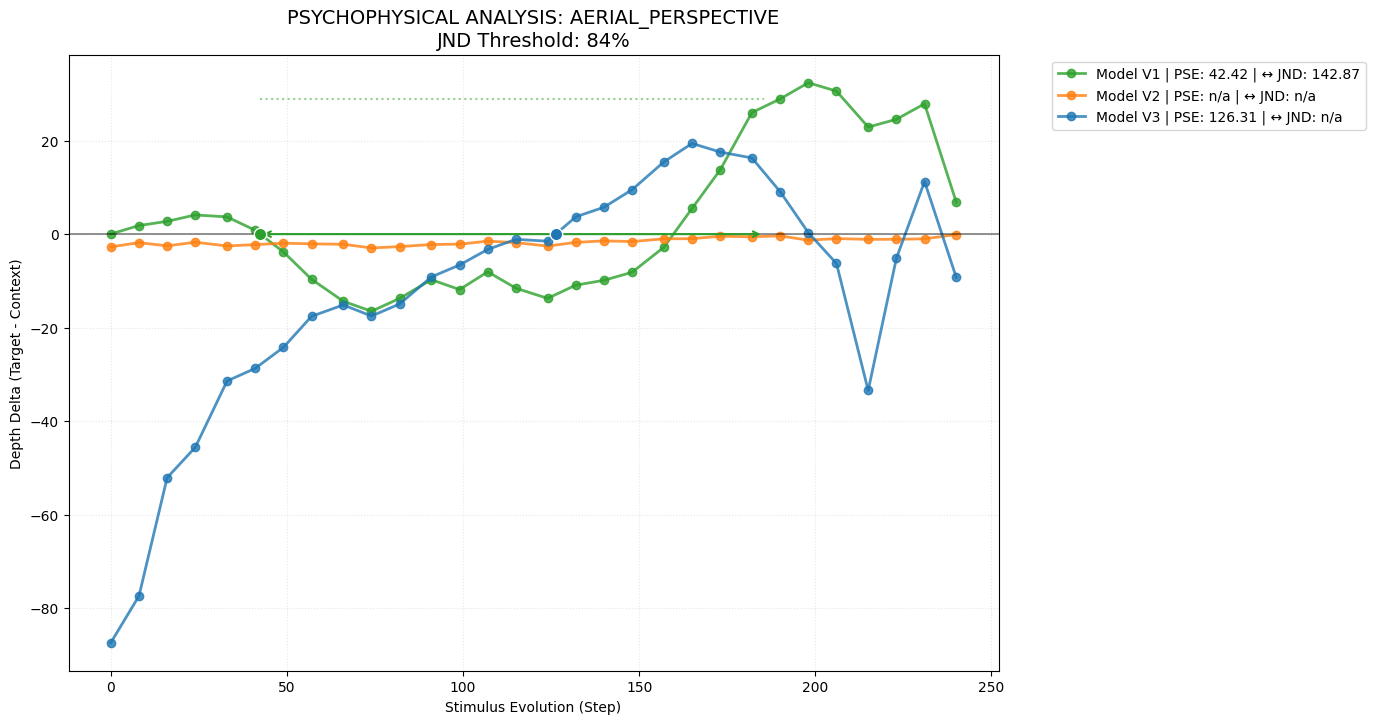

saved successfully in: Psychophysics_ROI_results\aerial_perspective\psychophysics_aerial_perspective.png


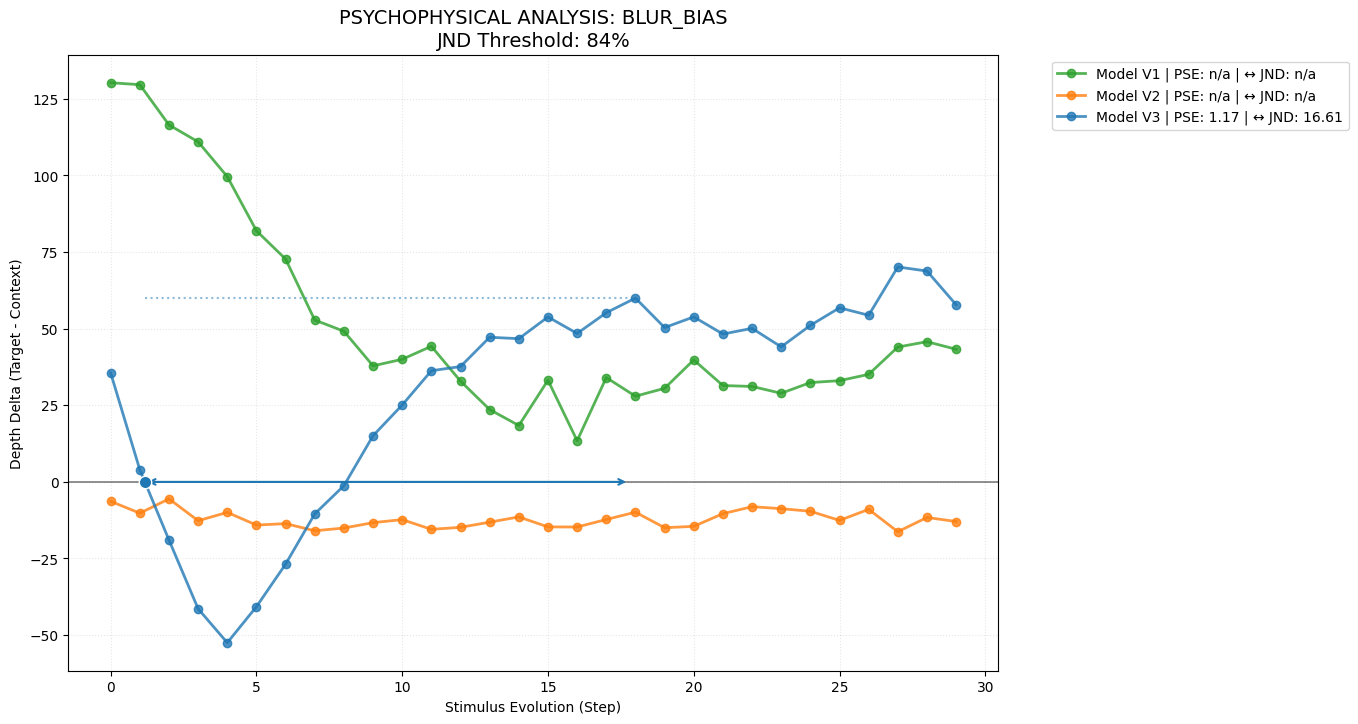

saved successfully in: Psychophysics_ROI_results\blur_bias\psychophysics_blur_bias.png


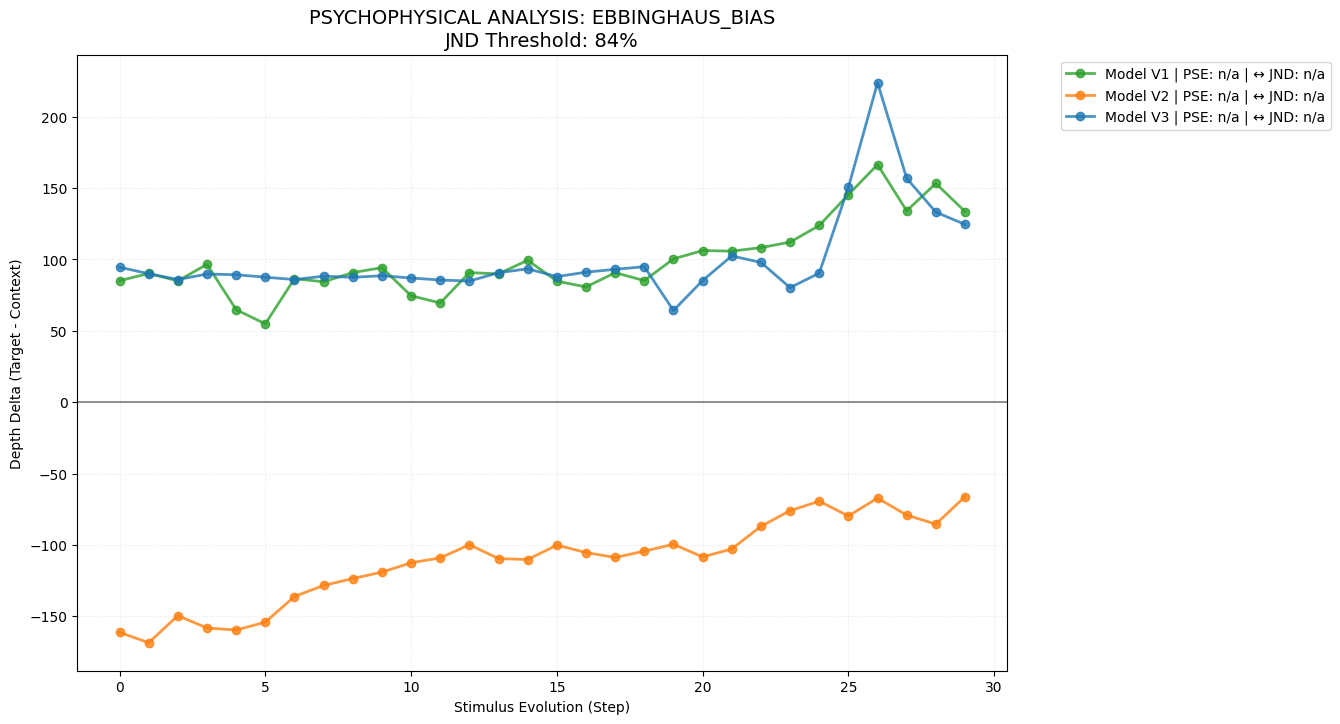

saved successfully in: Psychophysics_ROI_results\ebbinghaus_bias\psychophysics_ebbinghaus_bias.png


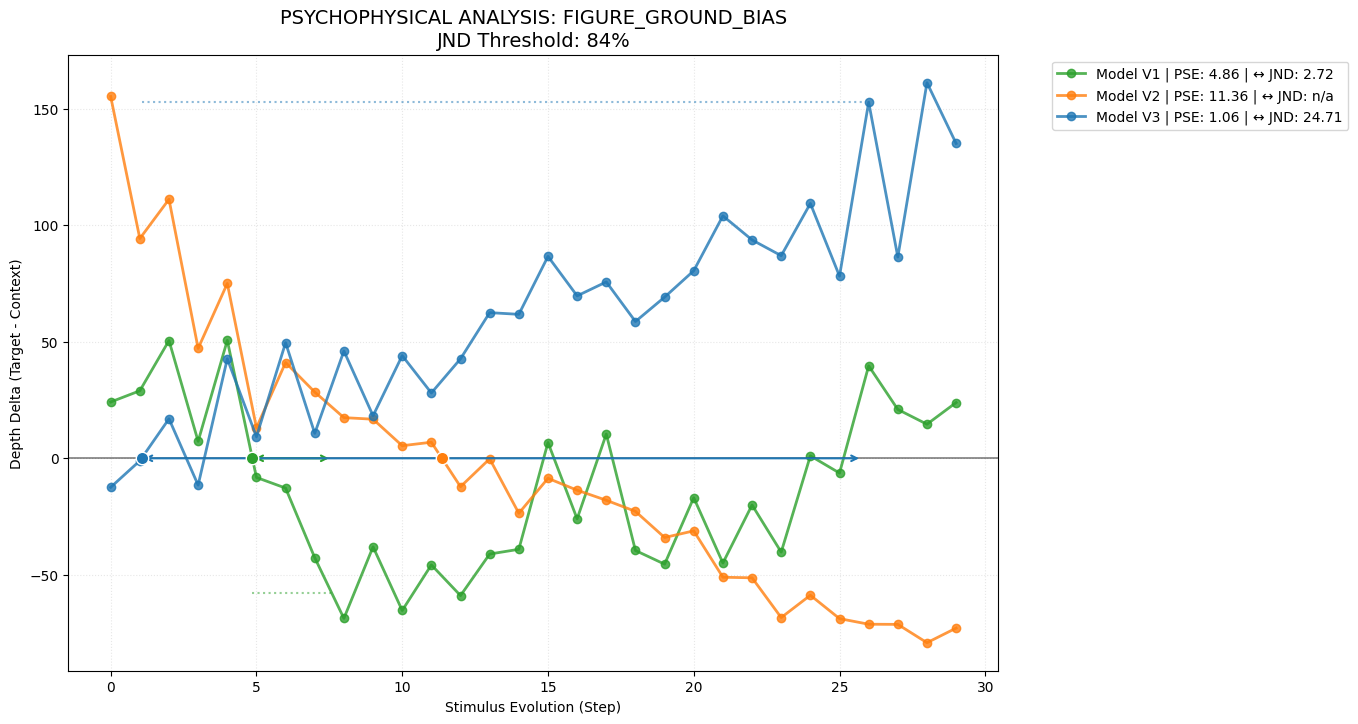

saved successfully in: Psychophysics_ROI_results\figure_ground_bias\psychophysics_figure_ground_bias.png


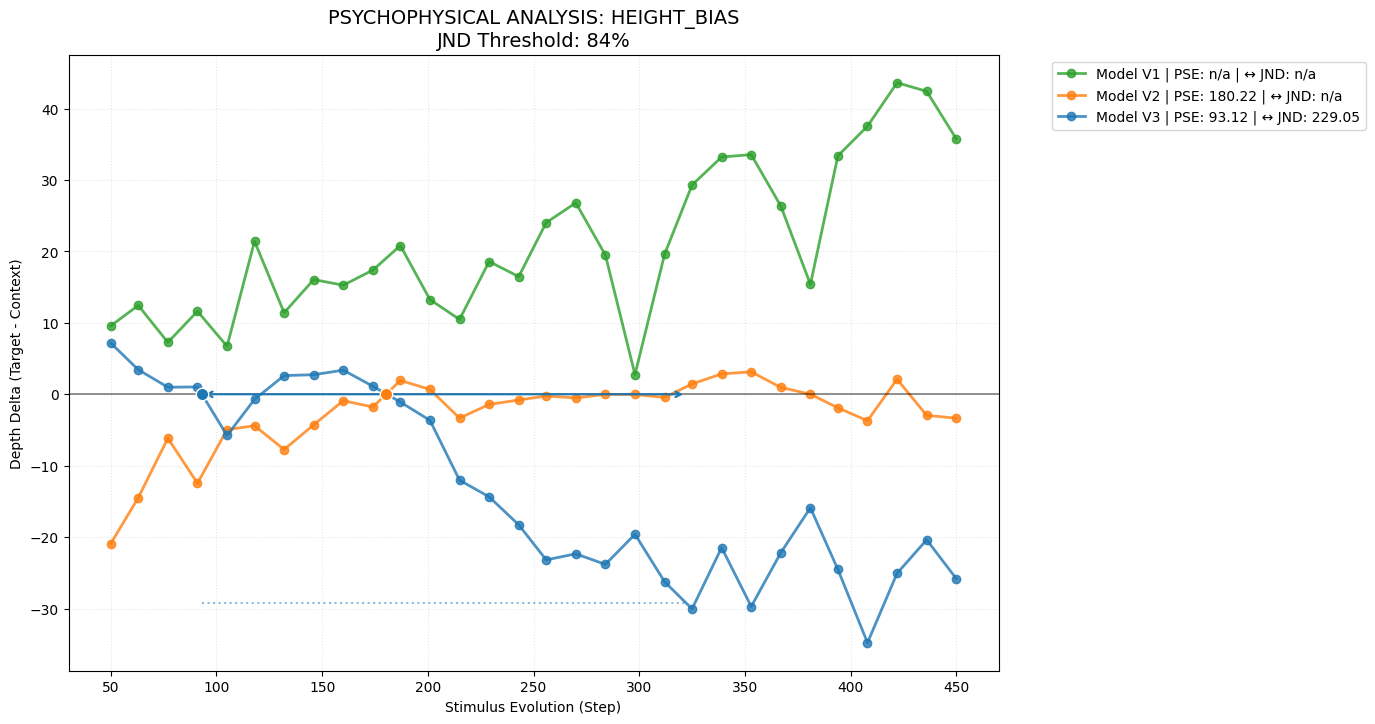

saved successfully in: Psychophysics_ROI_results\height_bias\psychophysics_height_bias.png


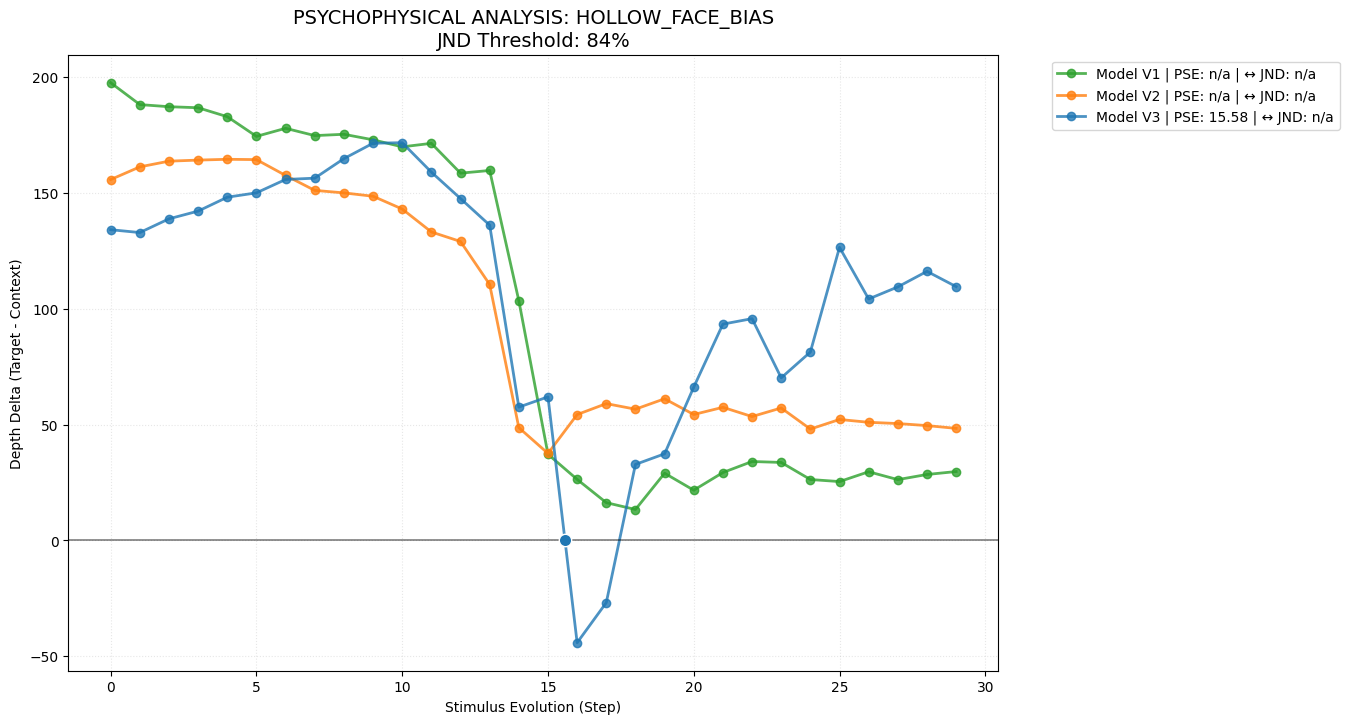

saved successfully in: Psychophysics_ROI_results\hollow_face_bias\psychophysics_hollow_face_bias.png


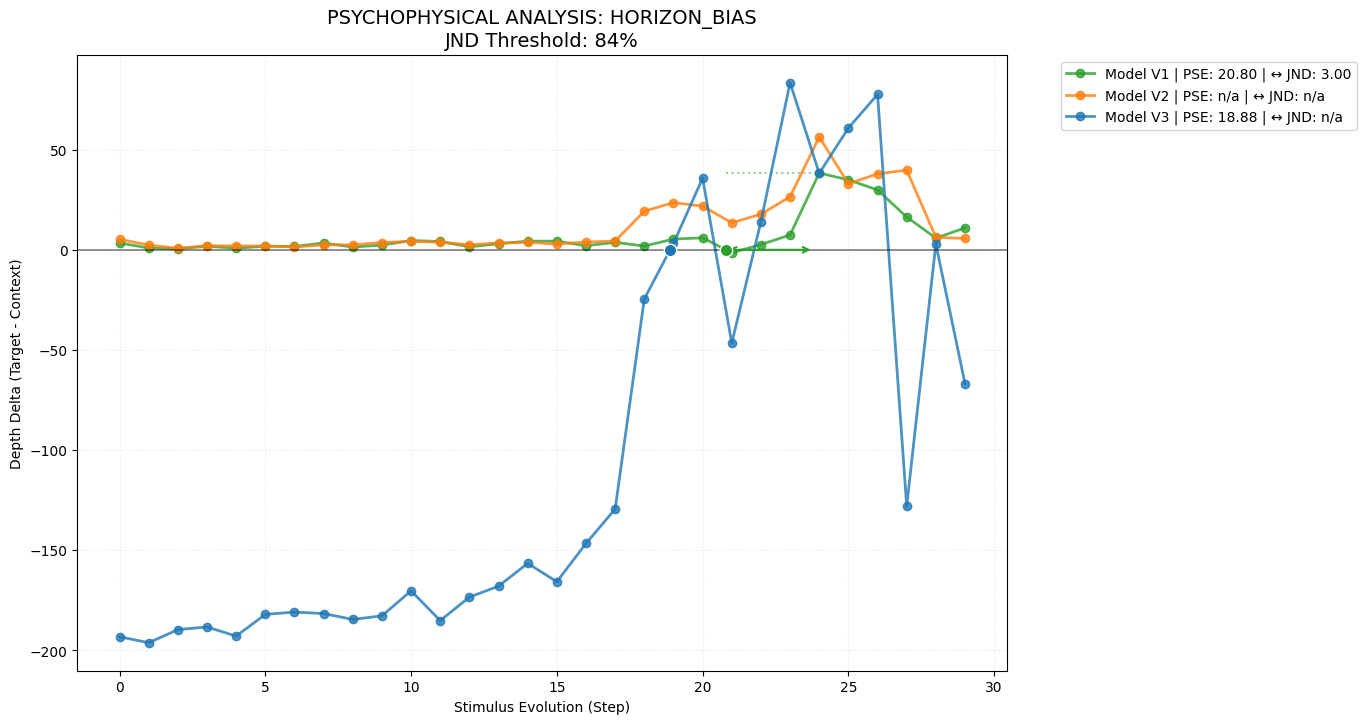

saved successfully in: Psychophysics_ROI_results\horizon_bias\psychophysics_horizon_bias.png


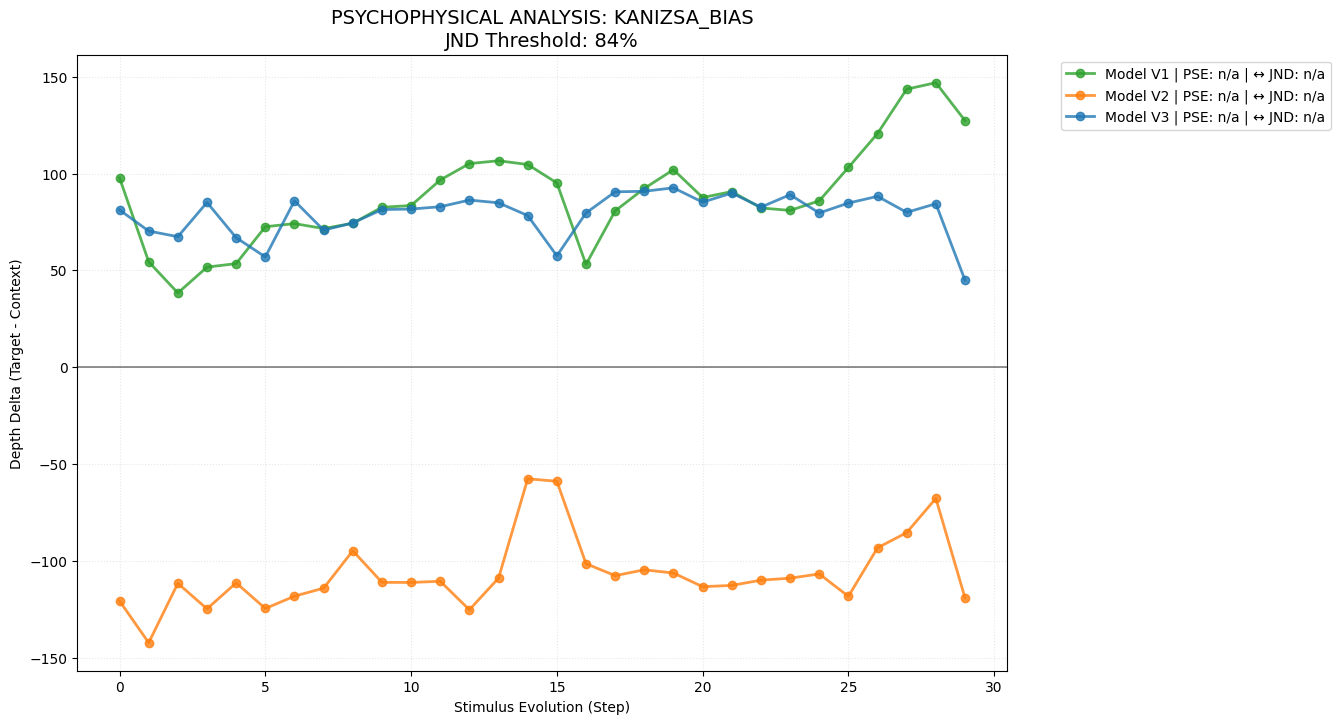

saved successfully in: Psychophysics_ROI_results\kanizsa_bias\psychophysics_kanizsa_bias.png


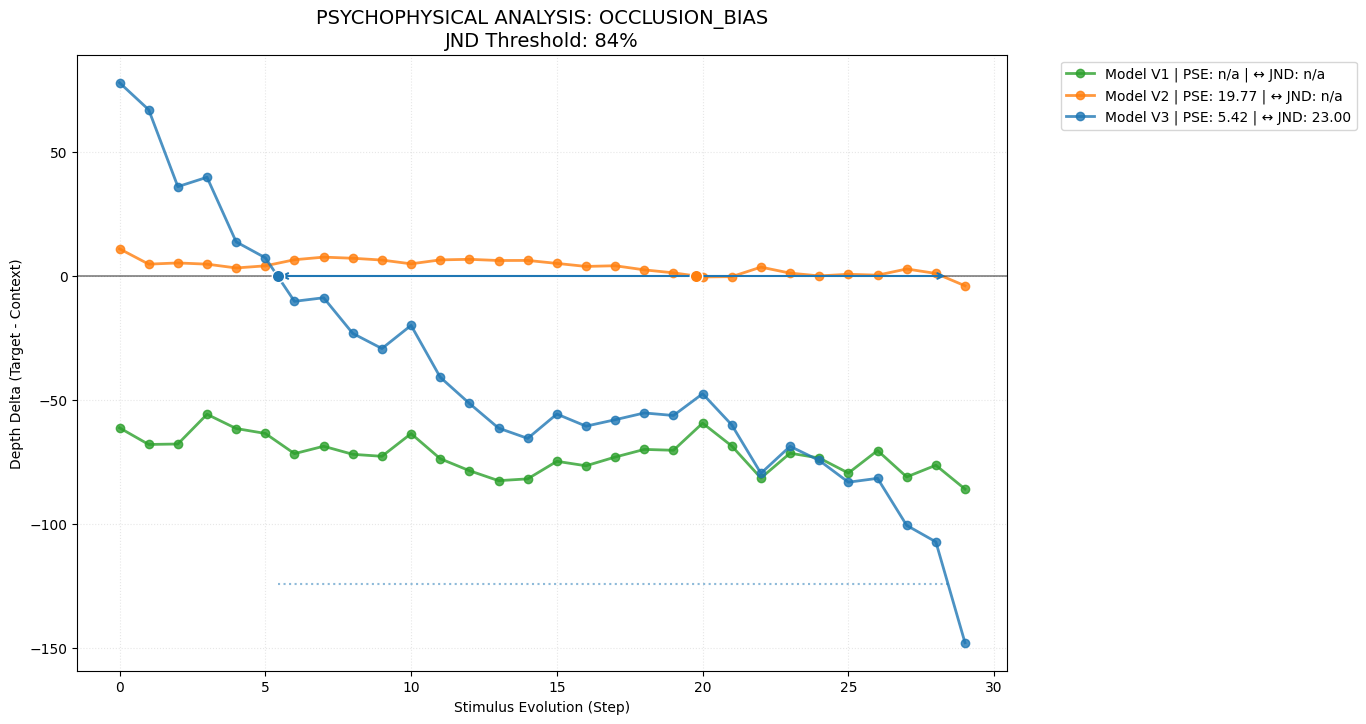

saved successfully in: Psychophysics_ROI_results\occlusion_bias\psychophysics_occlusion_bias.png


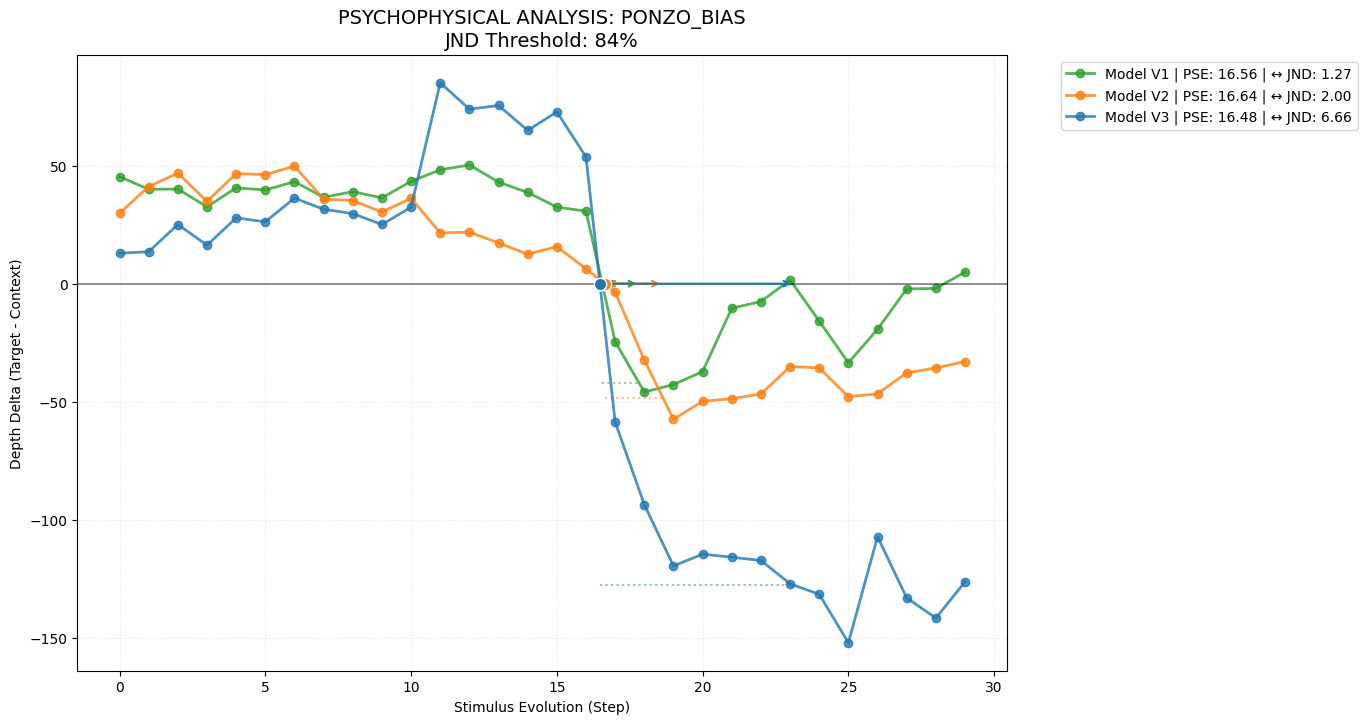

saved successfully in: Psychophysics_ROI_results\ponzo_bias\psychophysics_ponzo_bias.png


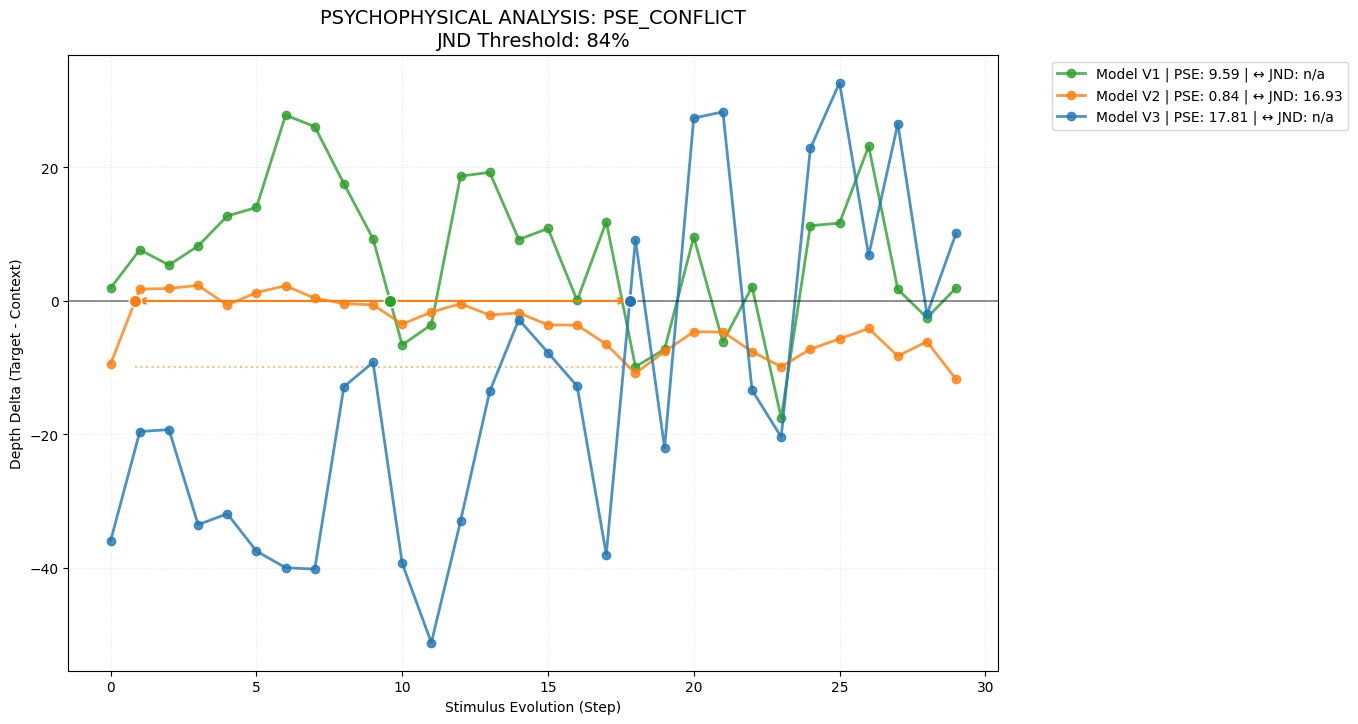

saved successfully in: Psychophysics_ROI_results\pse_conflict\psychophysics_pse_conflict.png


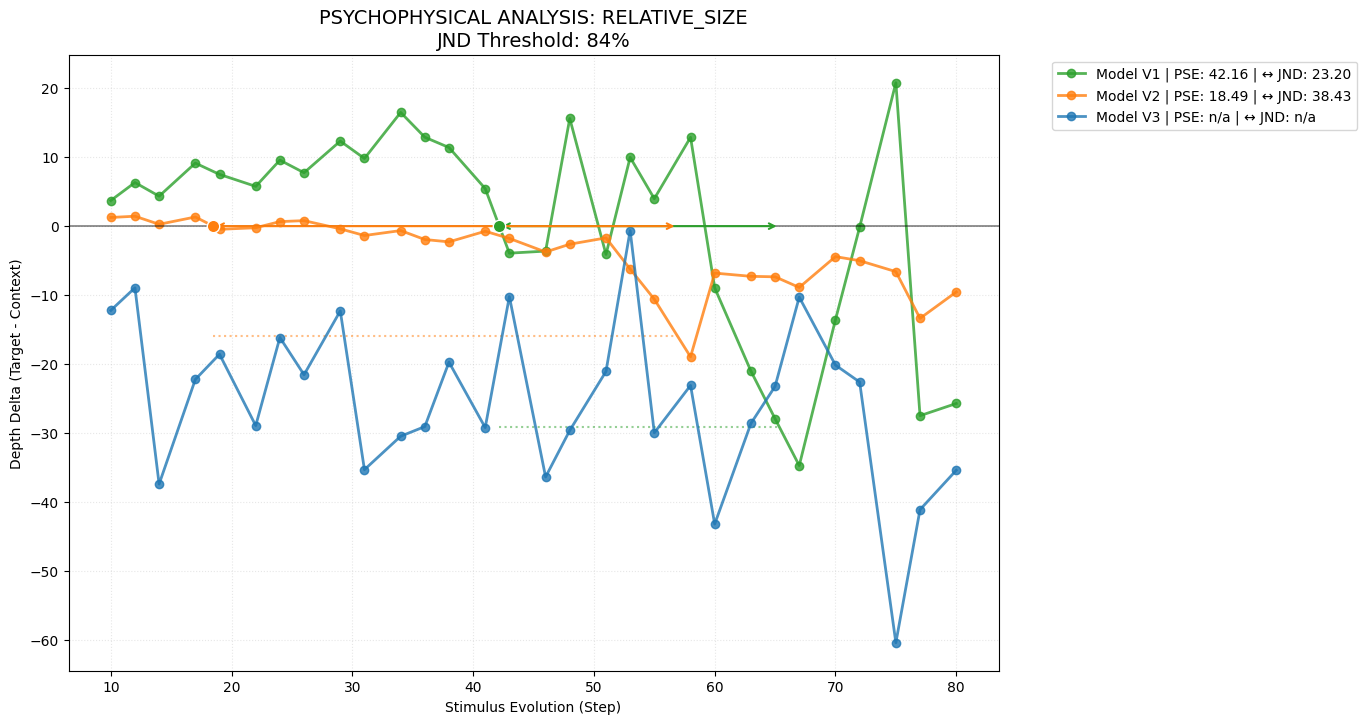

saved successfully in: Psychophysics_ROI_results\relative_size\psychophysics_relative_size.png


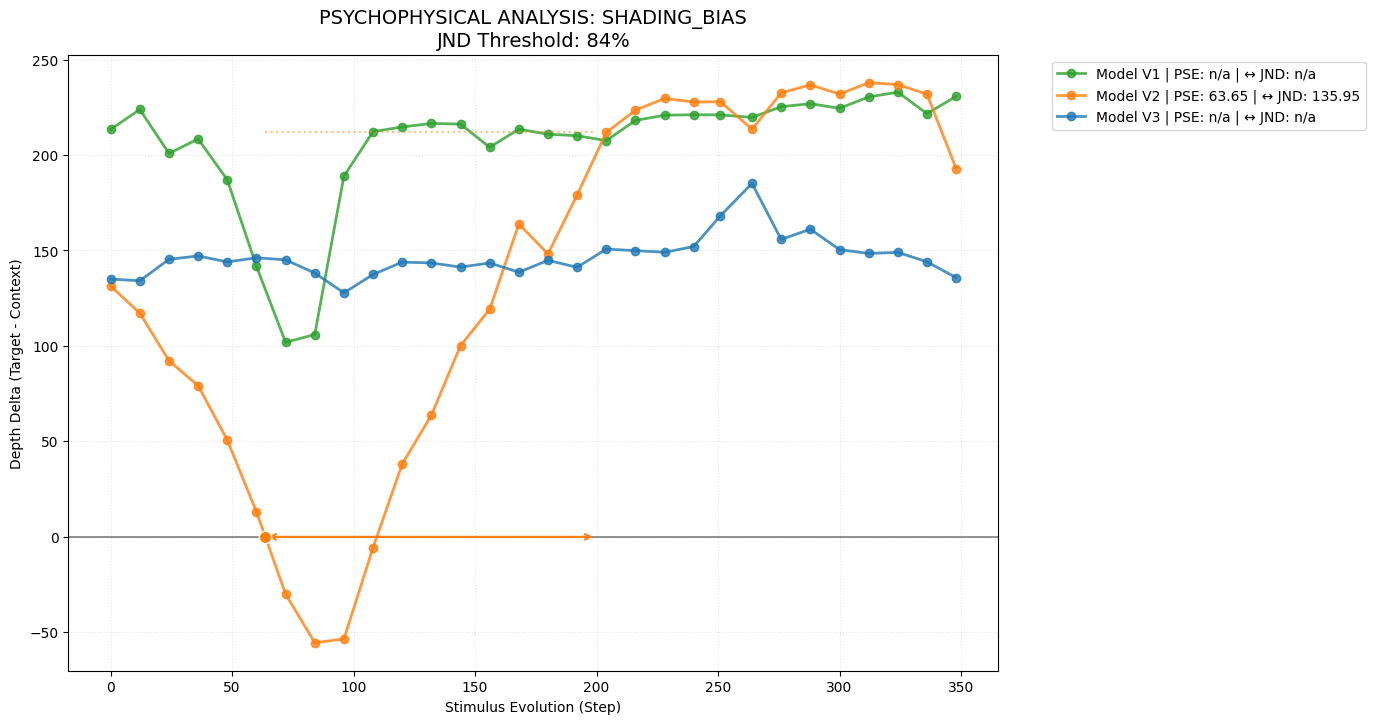

saved successfully in: Psychophysics_ROI_results\shading_bias\psychophysics_shading_bias.png


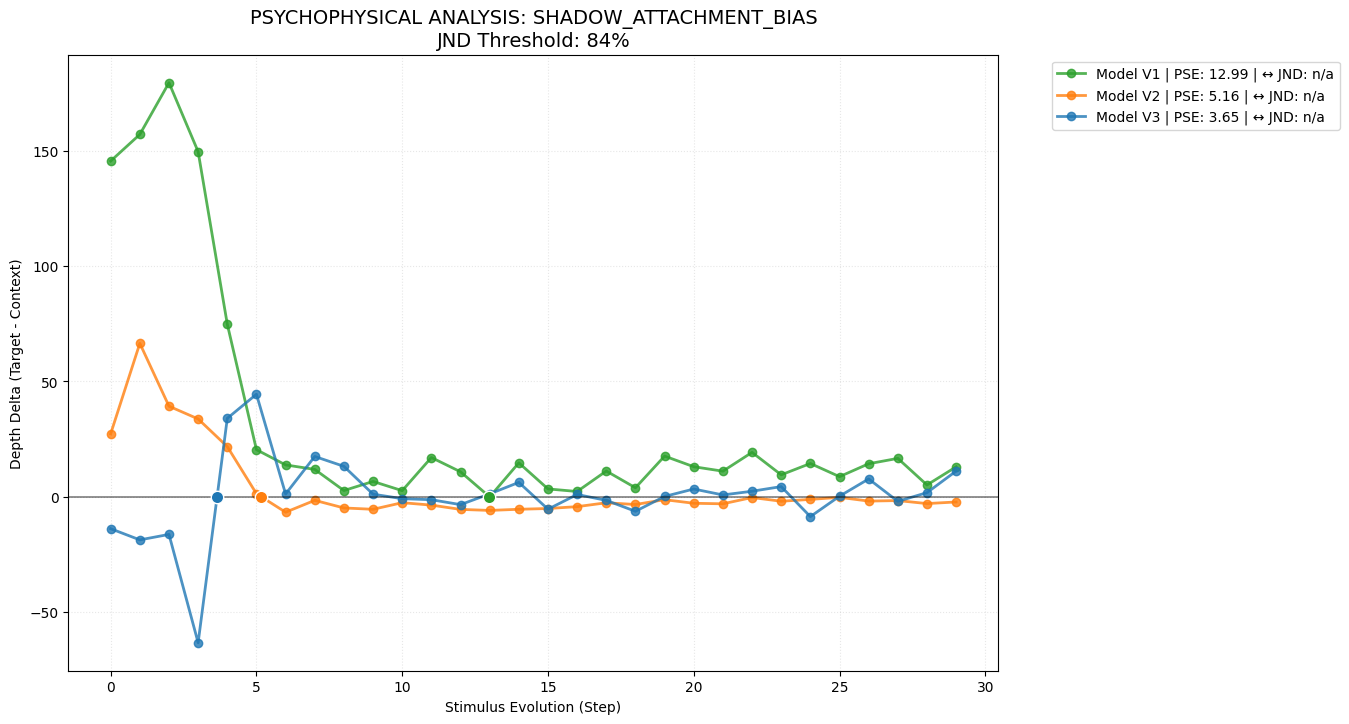

saved successfully in: Psychophysics_ROI_results\shadow_attachment_bias\psychophysics_shadow_attachment_bias.png


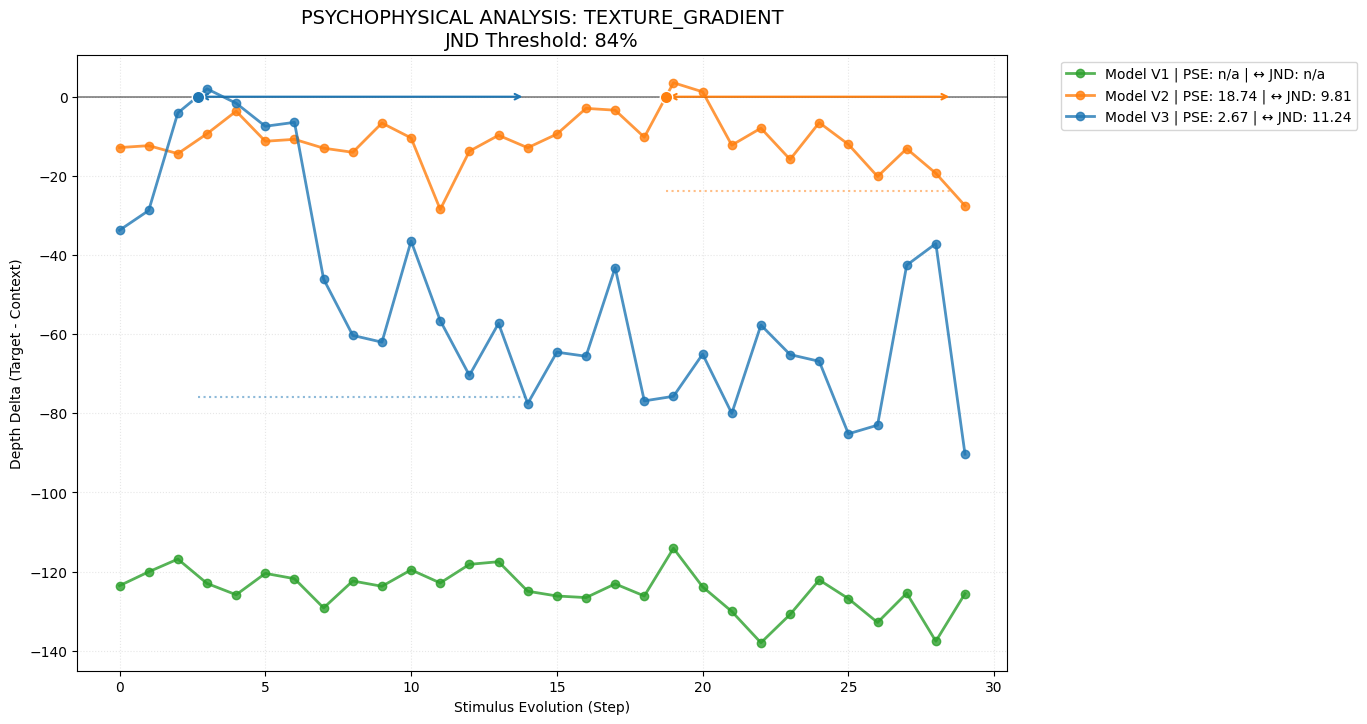

saved successfully in: Psychophysics_ROI_results\texture_gradient\psychophysics_texture_gradient.png


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def analyze_all_models_comparison(csv_path, category_name, threshold_pct=0.84):
    # load database
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"error: file {csv_path} not found")
        return

    # cleanup and formatting
    df = df[df['category'] != '---']
    df['mean_intensity'] = pd.to_numeric(df['mean_intensity'], errors='coerce')
    df['roi_id'] = pd.to_numeric(df['roi_id'], errors='coerce')
    
    # regex to get step from image name
    df['step'] = df['image'].str.extract(r'_(\d+)\.')[0].astype(float)
    df = df.dropna(subset=['step', 'mean_intensity'])
    df['step'] = df['step'].astype(int)

    # filter experiment data
    cat_df = df[df['category'].str.strip() == category_name].copy()
    cat_df = cat_df.drop_duplicates(subset=['model', 'step', 'roi_id'], keep='last')
    
    if cat_df.empty: return

    models = ['v1', 'v2', 'v3']
    colors = {'v1': '#2ca02c', 'v2': '#ff7f0e', 'v3': '#1f77b4'} 
    
    plt.figure(figsize=(12, 8))
    
    for model in models:
        model_df = cat_df[cat_df['model'] == model]
        if model_df.empty: continue
        
        # separate target and context (roi 1 vs roi 2)
        r1 = model_df[model_df['roi_id'] == 1].sort_values('step')
        r2 = model_df[model_df['roi_id'] == 2].sort_values('step')
        
        if not r1.empty and not r2.empty:
            steps = r1['step'].values
            y_diff = r1.set_index('step')['mean_intensity'] - r2.set_index('step')['mean_intensity']
            y_values = y_diff.values
            
            # plot main curve
            line, = plt.plot(steps, y_values, color=colors[model], linewidth=2, marker='o', alpha=0.8)

            # 1. calculate pse (crossover at zero)
            pse_x = None
            for i in range(len(steps) - 1):
                if y_values[i] * y_values[i+1] <= 0:
                    # linear interpolation for pse
                    weight = abs(y_values[i]) / (max(abs(y_values[i]) + abs(y_values[i+1]), 1e-6))
                    pse_x = steps[i] + weight * (steps[i+1] - steps[i])
                    plt.scatter([pse_x], [0], color=colors[model], s=80, edgecolors='white', zorder=5)
                    break

            # 2. calculate jnd (distance from pse to threshold)
            jnd_val = None
            max_delta = np.max(np.abs(y_values))
            threshold_target = max_delta * threshold_pct
            
            for i in range(len(steps) - 1):
                if pse_x is not None and steps[i] >= (pse_x - 1):
                    # check if the absolute value crosses the jnd threshold
                    if abs(y_values[i]) <= threshold_target <= abs(y_values[i+1]):
                        weight = (threshold_target - abs(y_values[i])) / (max(abs(y_values[i+1]) - abs(y_values[i]), 1e-6))
                        threshold_step = steps[i] + weight * (steps[i+1] - steps[i])
                        jnd_val = threshold_step - pse_x
                        
                        # draw jnd visual markers
                        plt.hlines(y=y_values[i+1] if y_values[i+1] > 0 else -threshold_target, 
                                   xmin=pse_x, xmax=threshold_step, color=colors[model], linestyle=':', alpha=0.5)
                        plt.annotate('', xy=(threshold_step, 0), xytext=(pse_x, 0),
                                     arrowprops=dict(arrowstyle='<->', color=colors[model], lw=1.5))
                        break

            # update legend with 2 decimal precision and jnd symbol
            pse_str = f"{pse_x:.2f}" if pse_x is not None else "n/a"
            jnd_str = f"{jnd_val:.2f}" if jnd_val is not None else "n/a"
            line.set_label(f'Model {model.upper()} | PSE: {pse_str} | ↔ JND: {jnd_str}')

    # final plot styling
    plt.axhline(y=0, color='black', linewidth=1.2, alpha=0.5)
    plt.title(f'PSYCHOPHYSICAL ANALYSIS: {category_name.upper()}\nJND Threshold: {threshold_pct*100:.0f}%', fontsize=14)
    plt.xlabel('Stimulus Evolution (Step)')
    plt.ylabel('Depth Delta (Target - Context)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.3)
    
    # save structured results in specific experiment folders
    # base_dir is now the parent folder of all experiments
    base_dir = "Psychophysics_ROI_results"
    exp_dir = os.path.join(base_dir, category_name)
    
    # check if directory exists (it should, as the frames are there)
    if not os.path.exists(exp_dir): os.makedirs(exp_dir)
    
    # save plot inside the folder of the specific experiment
    save_path = os.path.join(exp_dir, f"psychophysics_{category_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close() # close plot to save memory
    print(f"saved successfully in: {save_path}")

def run_full_analysis(csv_path):
    # automatic iterator for all experiments in the csv
    try:
        df = pd.read_csv(csv_path)
        categories = df[df['category'] != '---']['category'].unique()
        for cat in categories:
            analyze_all_models_comparison(csv_path, cat)
    except Exception as e:
        print(f"error during analysis: {e}")

# to run the script:
run_full_analysis("Psychophysics_ROI_results/tfg_roi_metrics.csv")